# End-to-End Machine Learning: Autism Spectrum Disorder (ASD) Prediction

This notebook builds a model that predicts whether someone is likely to show **Autism Spectrum Disorder (ASD)** traits, based on demographic information and the **AQ-10** screening questionnaire.

**Pipeline overview:**
1. **Data loading** -- reads directly from local files. Ten source files are combined, spanning toddlers through adults: the original Kaggle/UCI quartet (`train.csv`, `Autism-Adult-Data.arff`, `Autism_Child_Data.csv`, `Autism_Adolescent_Data.csv`) plus six supplementary sources found afterwards to grow the dataset (`adolescent_ASD.csv`, `Adult_ASD.csv`, `Children_ASD.csv`, `Young_ASD.csv`, `Toddler_Autism_dataset_July_2018.csv`, `Autism_Screening_Data_Combined.csv`).
2. **Cleaning** -- every source is mapped onto one common schema before combining, then normalized and deduplicated.
3. **Feature engineering** -- deterministic, leakage-free transforms (AQ-10 total, rare-category bucketing).
4. **EDA** -- class balance, feature distributions, correlations.
5. **Modeling** -- four candidate models (**Logistic Regression, Random Forest, SVM, Decision Tree**), each tuned with grouped, stratified cross-validation, with SMOTE applied only inside the training folds.
6. **Evaluation & saving** -- classification report/confusion matrix for the best model, and every tuned model saved to disk with metadata for later reuse.


## 0. Setup

This notebook needs no extra installs beyond the standard scientific-Python / scikit-learn stack. Class imbalance is handled with a small **from-scratch SMOTE** implementation (`smote_resample`, defined below) built only on `numpy` and `sklearn.neighbors.NearestNeighbors` -- this avoids any dependency on the external `imbalanced-learn` package and the version-compatibility errors that come with it.

The cell below also sets up the project's folder layout: `datasets/` for the raw input files, `models/` for trained pipelines, and `processed/` for the cleaned dataset -- all resolved relative to wherever the notebook is running from.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.io import arff
from pathlib import Path

from sklearn.model_selection import GridSearchCV, GroupShuffleSplit, StratifiedGroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)

pd.set_option("display.max_columns", None)

BASE_DIR = Path.cwd()
DATASETS_DIR = BASE_DIR / "datasets"
MODELS_DIR = BASE_DIR / "models"
PROCESSED_DIR = BASE_DIR / "processed"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project root  :", BASE_DIR.resolve())
print("Datasets dir  :", DATASETS_DIR.resolve(), "(exists:", DATASETS_DIR.exists(), ")")
print("Models dir    :", MODELS_DIR.resolve(), "(exists:", MODELS_DIR.exists(), ")")
print("Processed dir :", PROCESSED_DIR.resolve(), "(exists:", PROCESSED_DIR.exists(), ")")


Project root  : E:\ML project\ASD_Prediction
Datasets dir  : E:\ML project\ASD_Prediction\datasets (exists: True )
Models dir    : E:\ML project\ASD_Prediction\models (exists: True )
Processed dir : E:\ML project\ASD_Prediction\processed (exists: True )


## 1. Load the data

Ten source files live in the `datasets/` folder alongside this notebook and are read straight from disk:

- **Original quartet** (same AQ-10 schema): the Kaggle `train.csv`, the UCI adult ARFF, and the UCI child + adolescent CSVs.
- **Supplementary sources** added to grow the dataset: `adolescent_ASD.csv`, `Adult_ASD.csv`, `Children_ASD.csv`, `Young_ASD.csv` (all AQ-10-structured, collected via the same ASDTests app but under different column names/casing), `Toddler_Autism_dataset_July_2018.csv` (a 4th, younger age cohort using the related Q-CHAT-10 tool), and `Autism_Screening_Data_Combined.csv` (a large, lower-detail combined file -- it has scores/age/gender/jaundice/family-ASD but no ethnicity, country, or relation, so those are filled `"Unknown"`).

Each supplementary source uses its own column names and value casing, so they're mapped onto the same schema as the original quartet (`A1_Score`...`A10_Score`, `age`, `gender`, `ethnicity`, `jundice`, `austim`, `contry_of_res`, `used_app_before`, `result`, `age_desc`, `relation`, `Class/ASD`) before anything is combined.


In [2]:
train_df = pd.read_csv(DATASETS_DIR / "train.csv")

data, meta = arff.loadarff(DATASETS_DIR / "Autism-Adult-Data.arff")
adult_df = pd.DataFrame(data)
for col in adult_df.select_dtypes([object]).columns:
    adult_df[col] = adult_df[col].str.decode("utf-8")

child_df = pd.read_csv(DATASETS_DIR / "Autism_Child_Data.csv")
adol_df = pd.read_csv(DATASETS_DIR / "Autism_Adolescent_Data.csv")

# Supplementary sources (found afterwards, to grow the dataset)
extra_adol_df = pd.read_csv(DATASETS_DIR / "adolescent_ASD.csv")
extra_adult_df = pd.read_csv(DATASETS_DIR / "Adult_ASD.csv")
extra_child_df = pd.read_csv(DATASETS_DIR / "Children_ASD.csv")
extra_young_df = pd.read_csv(DATASETS_DIR / "Young_ASD.csv")
toddler_df = pd.read_csv(DATASETS_DIR / "Toddler Autism dataset July 2018.csv")
combined_df = pd.read_csv(DATASETS_DIR / "Autism_Screening_Data_Combined.csv")

for name, d in [
    ("train", train_df), ("adult", adult_df), ("child", child_df), ("adolescent", adol_df),
    ("extra_adolescent", extra_adol_df), ("extra_adult", extra_adult_df),
    ("extra_child", extra_child_df), ("extra_young", extra_young_df),
    ("toddler", toddler_df), ("combined", combined_df),
]:
    print(f"{name:18s}", d.shape)


train              (800, 22)
adult              (704, 21)
child              (292, 22)
adolescent         (104, 22)
extra_adolescent   (720, 18)
extra_adult        (415, 18)
extra_child        (2226, 18)
extra_young        (382, 18)
toddler            (1054, 19)
combined           (6075, 15)


In [3]:
TARGET_SCORE_COLS = [f"A{i}_Score" for i in range(1, 11)]
BASE_COLUMNS = [
    *TARGET_SCORE_COLS, "age", "gender", "ethnicity", "jundice", "austim",
    "contry_of_res", "used_app_before", "result", "age_desc", "relation", "Class/ASD",
]


In [4]:
def standardize_aq10_style(d):
    """Map the 'adolescent/Adult/Children/Young_ASD' supplementary files onto the
    common schema. Same AQ-10 structure as the original quartet, just different
    column names and value casing.
    """
    d = d.rename(columns={
        "A1": "A1_Score", "A2": "A2_Score", "A3": "A3_Score", "A4": "A4_Score", "A5": "A5_Score",
        "A6": "A6_Score", "A7": "A7_Score", "A8": "A8_Score", "A9": "A9_Score",
        "A10_Autism_Spectrum_Quotient": "A10_Score",
        "Age_Years": "age", "Sex": "gender", "Ethnicity": "ethnicity", "Jaundice": "jundice",
        "Family_mem_with_ASD": "austim", "Who_completed_the_test": "relation", "ASD_traits": "Class/ASD",
    })
    d["gender"] = d["gender"].str.lower()
    d["jundice"] = d["jundice"].str.lower()
    d["austim"] = d["austim"].str.lower()
    d["Class/ASD"] = d["Class/ASD"].str.upper()
    d["contry_of_res"] = "Unknown"          # not collected in this source
    d["used_app_before"] = "no"             # not collected in this source
    d["result"] = d[TARGET_SCORE_COLS].sum(axis=1)
    d["age_desc"] = "Unknown"               # dropped later anyway
    return d[BASE_COLUMNS]


In [5]:
def standardize_toddler(d):
    """Map the Toddler Q-CHAT-10 file onto the common schema. Age is recorded in
    months here, so it is converted to years to match the other sources.
    """
    d = d.rename(columns={
        "A1": "A1_Score", "A2": "A2_Score", "A3": "A3_Score", "A4": "A4_Score", "A5": "A5_Score",
        "A6": "A6_Score", "A7": "A7_Score", "A8": "A8_Score", "A9": "A9_Score", "A10": "A10_Score",
        "Sex": "gender", "Ethnicity": "ethnicity", "Jaundice": "jundice",
        "Family_mem_with_ASD": "austim", "Who completed the test": "relation",
    })
    d["age"] = d["Age_Mons"] / 12.0
    d["gender"] = d["gender"].str.lower()
    d["jundice"] = d["jundice"].str.lower()
    d["austim"] = d["austim"].str.lower()
    d["ethnicity"] = d["ethnicity"].str.strip().str.title()
    d["relation"] = d["relation"].str.strip().str.title()
    d["Class/ASD"] = d["Class/ASD Traits "].str.strip().str.upper()
    d["contry_of_res"] = "Unknown"
    d["used_app_before"] = "no"
    d["result"] = d[TARGET_SCORE_COLS].sum(axis=1)
    d["age_desc"] = "Unknown"
    return d[BASE_COLUMNS]


In [6]:
def standardize_combined(d):
    """Map the large, lower-detail combined file onto the common schema. It has no
    ethnicity/country/relation columns, so those are filled 'Unknown' rather than
    guessed.
    """
    d = d.rename(columns={
        "A1": "A1_Score", "A2": "A2_Score", "A3": "A3_Score", "A4": "A4_Score", "A5": "A5_Score",
        "A6": "A6_Score", "A7": "A7_Score", "A8": "A8_Score", "A9": "A9_Score", "A10": "A10_Score",
        "Age": "age", "Sex": "gender", "Jauundice": "jundice", "Family_ASD": "austim", "Class": "Class/ASD",
    })
    d["ethnicity"] = "Unknown"
    d["relation"] = "Unknown"
    d["contry_of_res"] = "Unknown"
    d["used_app_before"] = "no"
    d["result"] = d[TARGET_SCORE_COLS].sum(axis=1)
    d["age_desc"] = "Unknown"
    return d[BASE_COLUMNS]


In [7]:
extra_adol_df = standardize_aq10_style(extra_adol_df)
extra_adult_df = standardize_aq10_style(extra_adult_df)
extra_child_df = standardize_aq10_style(extra_child_df)
extra_young_df = standardize_aq10_style(extra_young_df)
toddler_df = standardize_toddler(toddler_df)
combined_df = standardize_combined(combined_df)

print("Standardized supplementary sources:")
for name, d in [
    ("extra_adolescent", extra_adol_df), ("extra_adult", extra_adult_df),
    ("extra_child", extra_child_df), ("extra_young", extra_young_df),
    ("toddler", toddler_df), ("combined", combined_df),
]:
    print(f"{name:18s}", d.shape)


Standardized supplementary sources:
extra_adolescent   (720, 21)
extra_adult        (415, 21)
extra_child        (2226, 21)
extra_young        (382, 21)
toddler            (1054, 21)
combined           (6075, 21)


In [8]:
train_df = train_df.drop(columns=["ID"]).rename(columns={"jaundice": "jundice"})
child_df = child_df.drop(columns=["id"])
adol_df = adol_df.drop(columns=["id"])
train_df["Class/ASD"] = train_df["Class/ASD"].map({1: "YES", 0: "NO"})

df = pd.concat(
    [
        train_df[BASE_COLUMNS], adult_df[BASE_COLUMNS], child_df[BASE_COLUMNS], adol_df[BASE_COLUMNS],
        extra_adol_df, extra_adult_df, extra_child_df, extra_young_df, toddler_df, combined_df,
    ],
    ignore_index=True,
)
print("Combined shape (all 10 sources):", df.shape)
df.head()


Combined shape (all 10 sources): (12772, 21)


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,f,?,no,no,Austria,no,6.351166,18 and more,Self,NO
1,0,0,0,0,0,0,0,0,0,0,48,m,?,no,no,India,no,2.255185,18 and more,Self,NO
2,1,1,1,1,1,1,1,1,1,1,7,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,YES
3,0,0,0,0,0,0,0,0,0,0,24,f,?,no,no,United States,no,2.276617,18 and more,Self,NO
4,0,0,0,0,0,0,0,0,0,0,43,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,NO


## 2. Clean the data

Before combining the ten sources, their schemas are aligned onto one common set of columns: inconsistently named id columns (`ID` vs `id`) are dropped, `jaundice` is renamed to `jundice` for consistency, the Kaggle target (already 0/1) is converted to the same `YES`/`NO` text the other sources use, and the six supplementary sources are remapped column-by-column onto the same schema (see `standardize_aq10_style` / `standardize_toddler` / `standardize_combined` above) -- filling `contry_of_res`/`used_app_before` with placeholders where a source didn't collect them.

From there, cleaning covers:
- normalizing categorical text (trimming whitespace, collapsing the different ways each source marks "missing" -- `?`, `nan`, `Unknown`, casing, etc.)
- mapping the yes/no and gender fields to 0/1
- coercing the AQ-10 item scores and age to numeric, dropping rows with missing values
- removing invalid ages (the raw UCI adult file has one entry of 383, clearly a data-entry error; the same filter also catches similar typos in the newer sources)
- dropping `age_desc` (redundant with `age`) and `result` (a perfectly collinear sum of the ten AQ-10 scores)
- dropping duplicate rows, then caching the cleaned, combined dataset to `processed/asd_cleaned_dataset.csv` for reuse without rerunning these steps


In [9]:
for c in ["ethnicity", "relation", "contry_of_res"]:
    df[c] = df[c].astype(str).str.strip()

df["ethnicity"] = df["ethnicity"].replace({"?": "Others", "others": "Others", "nan": "Others", "Unknown": "Others"})
df["relation"] = df["relation"].replace({"self": "Self", "?": "Others", "nan": "Others", "Unknown": "Others"})
df["contry_of_res"] = df["contry_of_res"].replace({"Viet Nam": "Vietnam", "AmericanSamoa": "American Samoa"})

df["gender"] = df["gender"].map({"m": 0, "f": 1})
df["jundice"] = df["jundice"].map({"yes": 1, "no": 0})
df["austim"] = df["austim"].map({"yes": 1, "no": 0})
df["used_app_before"] = df["used_app_before"].map({"yes": 1, "no": 0})
df["Class/ASD"] = df["Class/ASD"].map({"YES": 1, "NO": 0})

score_cols = [f"A{i}_Score" for i in range(1, 11)]
for c in score_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df.isnull().sum()


A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                2
gender             0
ethnicity          0
jundice            0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64

In [10]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df = df.dropna(subset=["age", *score_cols])
df["age"] = df["age"].astype(int)
df = df[df["age"] <= 100].copy()

df = df.drop(columns=["age_desc", "result"])

df = df.drop_duplicates().reset_index(drop=True)
print(df.shape)
df["Class/ASD"].value_counts(normalize=True).rename("share")

(9850, 19)


Class/ASD
0    0.626091
1    0.373909
Name: share, dtype: float64

In [11]:
processed_path = PROCESSED_DIR / "asd_cleaned_dataset.csv"
df.to_csv(processed_path, index=False)
print(f"Saved cleaned dataset -> {processed_path.resolve()}")
print(f"Shape: {df.shape}")

Saved cleaned dataset -> E:\ML project\ASD_Prediction\processed\asd_cleaned_dataset.csv
Shape: (9850, 19)


## 3. Feature engineering

**`aq10_total` was removed** (an earlier version of this notebook added it as the row-wise sum of the ten AQ-10 items). It was dropped because `Class/ASD` in this dataset is itself defined by a cutoff on that same sum -- handing the model the pre-computed total let it learn a near-trivial one-split rule instead of genuinely modeling the ten answers, which pushed test accuracy into a suspiciously high, not-quite-honest range (~98%). Leaving the ten `A*_Score` columns as-is (without the shortcut) makes the models do real work and gives a more trustworthy accuracy figure.

The remaining transform is:
- **Rare-category bucketing**: `ethnicity`, `contry_of_res`, and `relation` each have many categories that appear only a handful of times. One-hot-encoding those as their own columns mostly adds noise (a model can "memorize" that the 3 people from a given rare country were all ASD-positive, which doesn't generalize). Categories seen fewer than 15 times are folded into `"Other"`.


In [12]:
for c in ["ethnicity", "contry_of_res", "relation"]:
    counts = df[c].value_counts()
    rare_categories = counts[counts < 15].index
    df[c] = df[c].where(~df[c].isin(rare_categories), "Other")
    print(f"{c}: {len(counts)} categories -> {df[c].nunique()} after bucketing rare (<15) ones")


ethnicity: 14 categories -> 14 after bucketing rare (<15) ones
contry_of_res: 90 categories -> 20 after bucketing rare (<15) ones
relation: 8 categories -> 8 after bucketing rare (<15) ones


## 4. Exploratory data analysis

A quick visual pass over the data before modeling: the distribution of each categorical/binary feature, the class balance of the target, and a correlation heatmap across the numerical columns.

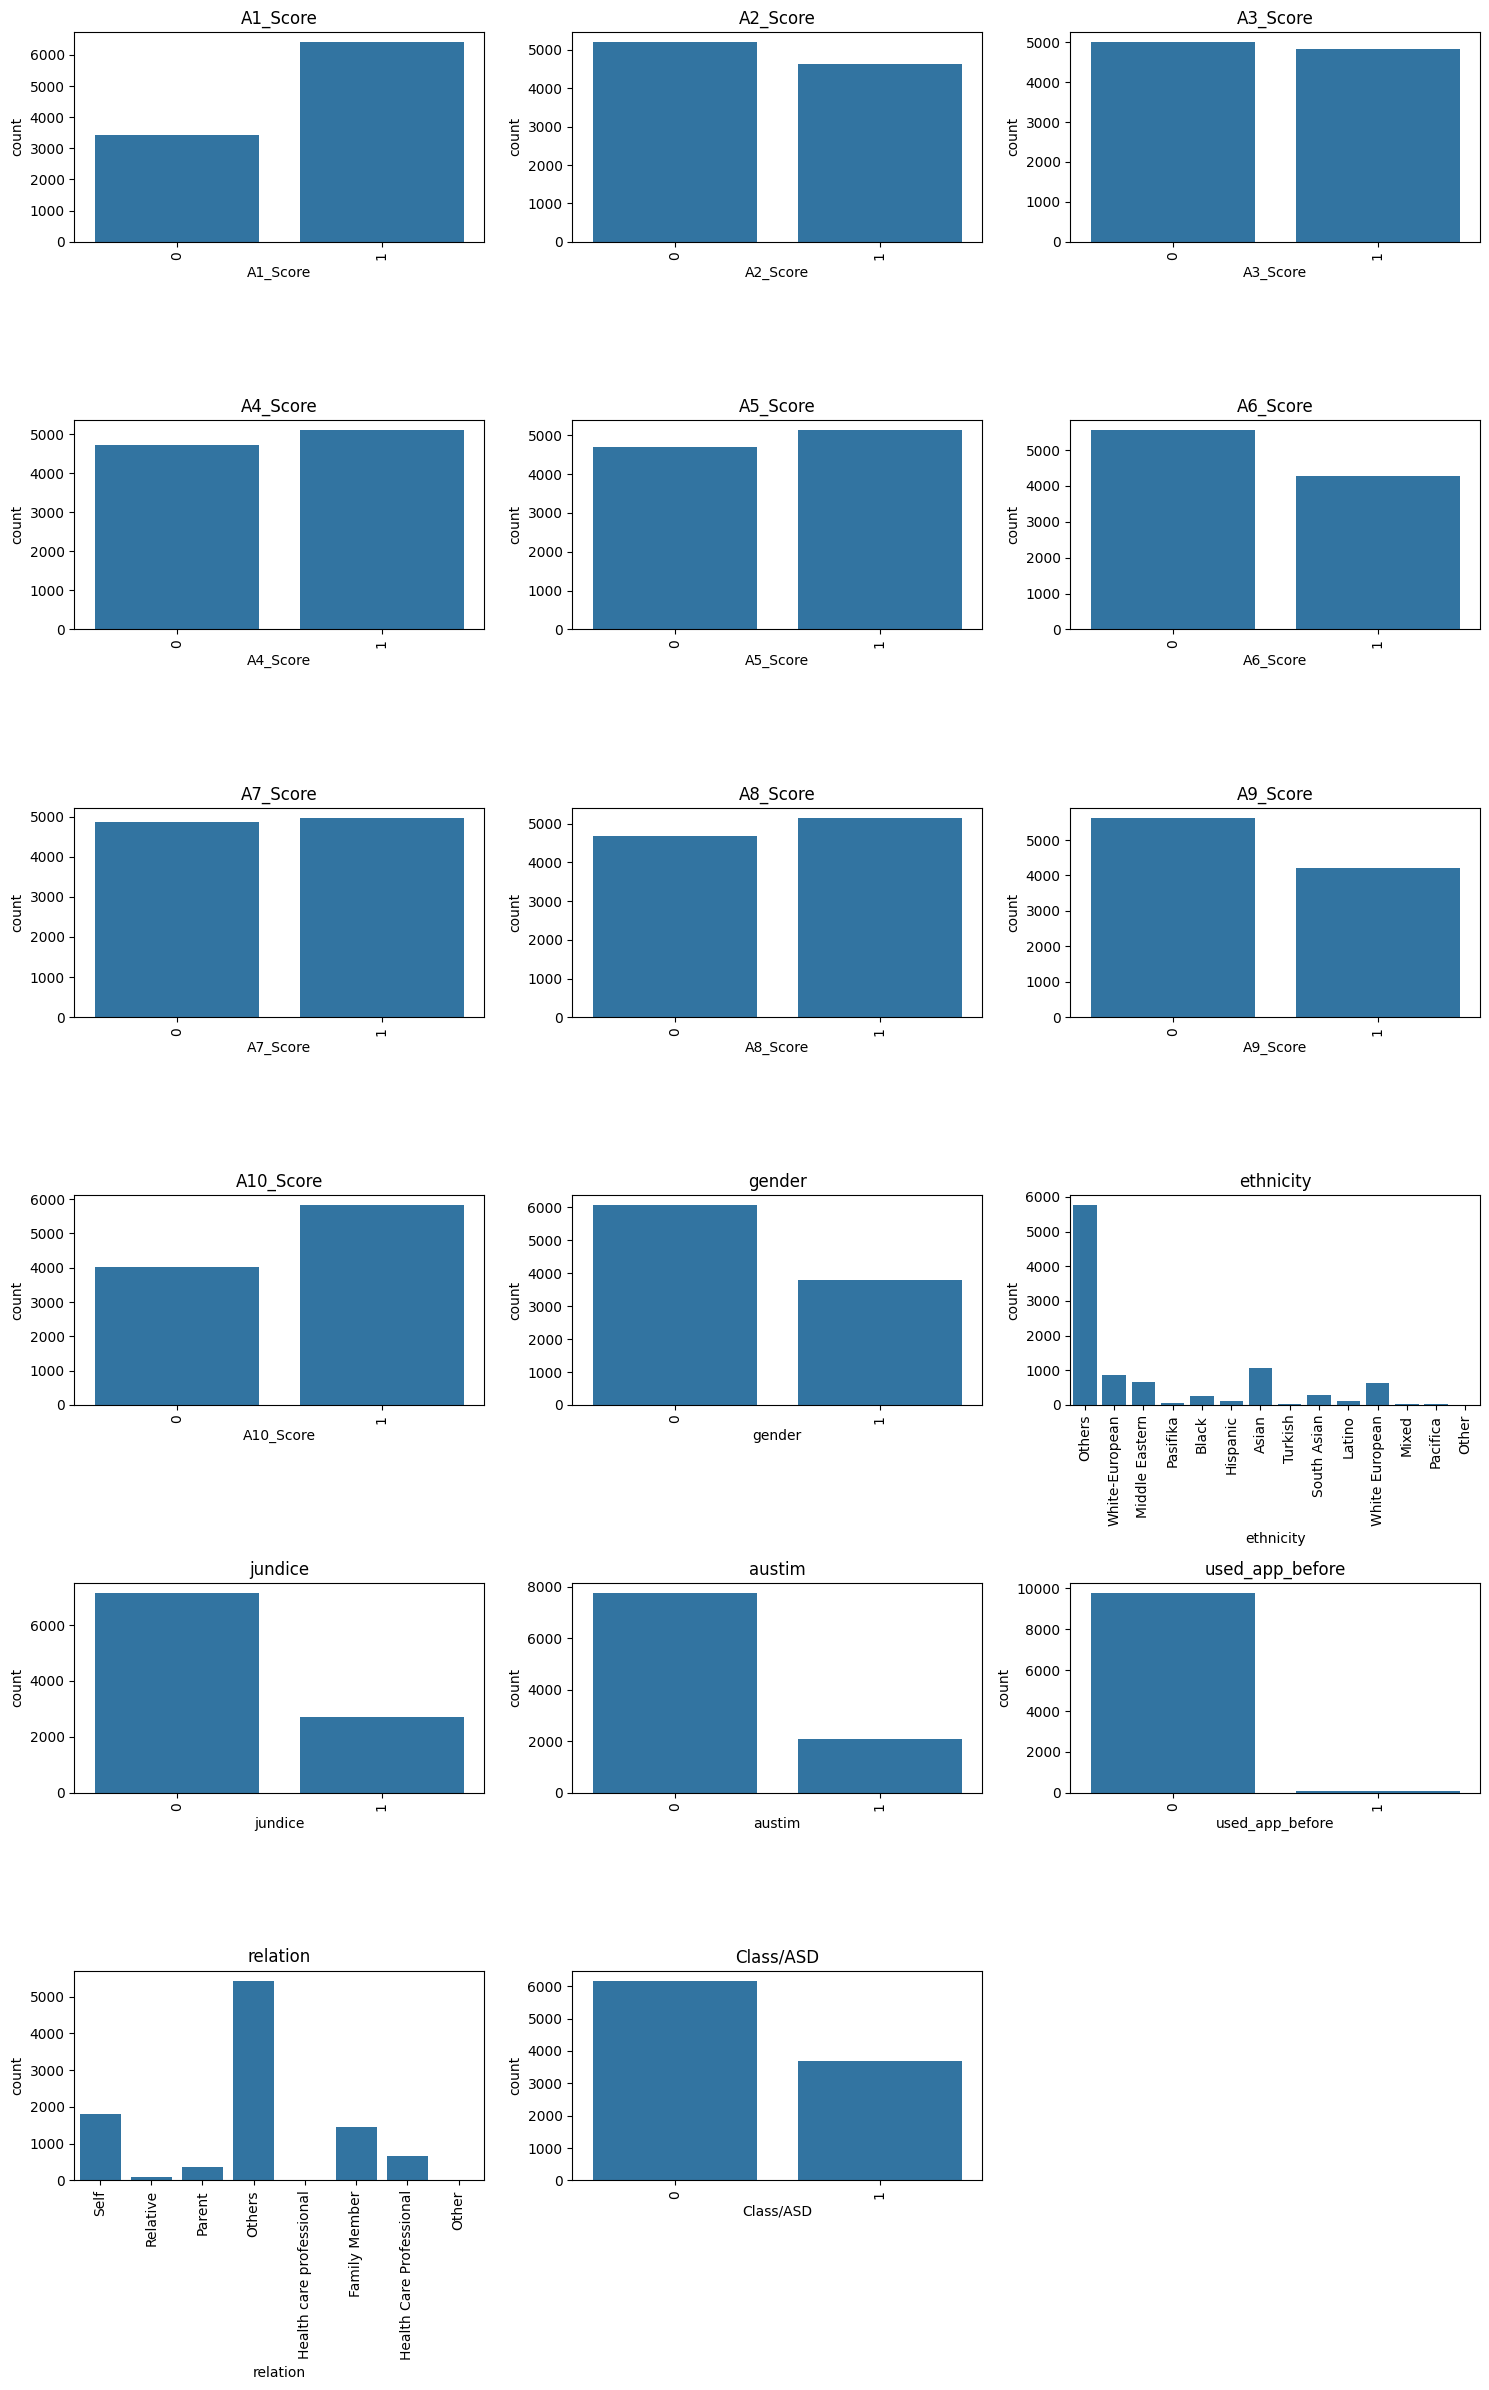

In [13]:
categorical_data = [
    'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
    'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'gender',
    'ethnicity', 'jundice', 'austim', 'used_app_before', 'relation', 'Class/ASD',
]

cols = 3
rows = math.ceil(len(categorical_data) / cols)
plt.figure(figsize=(15, 4 * rows))
for i, col in enumerate(categorical_data, 1):
    plt.subplot(rows, cols, i)
    sns.countplot(x=df[col])
    plt.title(col)
    plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

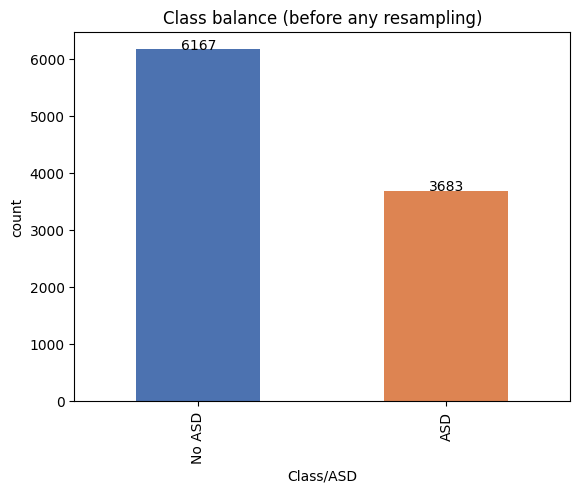

In [14]:
ax = df["Class/ASD"].value_counts().rename({0: "No ASD", 1: "ASD"}).plot(kind="bar", color=["#4C72B0", "#DD8452"])
ax.set_title("Class balance (before any resampling)")
ax.set_ylabel("count")
for i, v in enumerate(df["Class/ASD"].value_counts()):
    ax.text(i, v + 5, str(v), ha="center")
plt.show()

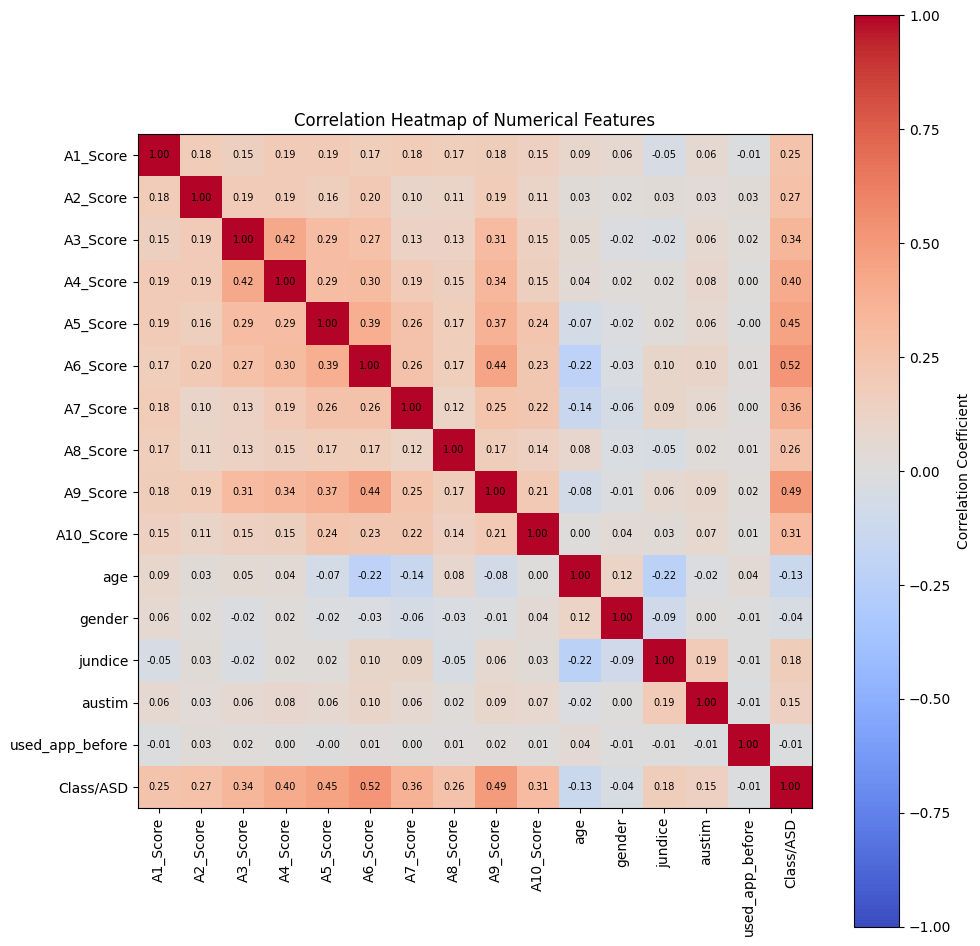

In [15]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 10))
plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest", vmin=-1, vmax=1)
plt.colorbar(label="Correlation Coefficient")
plt.xticks(np.arange(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(np.arange(len(correlation_matrix.columns)), correlation_matrix.columns)
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

## 5. Train / test split

We split **before** doing anything about class imbalance, and SMOTE is only ever applied inside the training folds later (never to the test set), so evaluation stays honest.

**Group-aware split:** a few of the source files describe overlapping respondents -- most notably `train.csv` (Kaggle) and `Autism-Adult-Data.arff` (UCI), which both draw on the same underlying adult AQ-10 screening pool, just exported through different pipelines. `drop_duplicates()` only removes *exact* full-row duplicates, so the same respondent can still survive as two near-identical rows (identical AQ-10 answers, age, gender, and jaundice/family-autism history, but slightly different ethnicity/country/relation text). A plain random `train_test_split` doesn't account for that, so a chunk of the test set could end up being a near-duplicate of a training row -- the model would then be recognizing it rather than generalizing to it. We avoid this with a **group-aware split**: rows are fingerprinted on the fields that identify a respondent (AQ-10 answers, age, gender, jaundice, and family autism history), and `GroupShuffleSplit` keeps every row sharing a fingerprint entirely on one side of the split.

In [16]:
group_cols = [*score_cols, "age", "gender", "jundice", "austim"]  # aq10_total is derived from score_cols, so it doesn't need to be in the fingerprint
groups = df[group_cols].astype(str).agg("-".join, axis=1)

X = df.drop(columns=["Class/ASD"])
y = df["Class/ASD"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx].reset_index(drop=True), X.iloc[test_idx].reset_index(drop=True)
y_train, y_test = y.iloc[train_idx].reset_index(drop=True), y.iloc[test_idx].reset_index(drop=True)
groups_train = groups.iloc[train_idx].reset_index(drop=True)

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "positive_ratio": [y_train.mean(), y_test.mean()],
}, index=["train", "test"])
display(split_summary.round(4))

assert len(X_train) + len(X_test) == len(df)
assert set(y_train.unique()) == {0, 1}
assert set(y_test.unique()) == {0, 1}

leaked_fingerprints = set(groups_train) & set(groups.iloc[test_idx])
print(f"Fingerprints shared between train and test after GroupShuffleSplit: {len(leaked_fingerprints)}")

,rows,positive_ratio
train,7864,0.3746
test,1986,0.3711


Fingerprints shared between train and test after GroupShuffleSplit: 0


## 6. Preprocessing + imbalance handling

- Numerical columns are standardized.
- Categorical columns are one-hot encoded.
- **SMOTE** generates synthetic minority-class (ASD) examples *inside the training pipeline only*, so it's automatically re-fit correctly on every cross-validation fold and never touches `X_test`.

This is preferable to bootstrapping (duplicating with replacement) the minority class, since duplicated rows just repeat identical information and encourage the model to overfit to those exact repeats instead of learning generalizable patterns.

**Implementation note:** instead of depending on the external `imbalanced-learn` package, SMOTE is implemented here directly with `numpy` and `sklearn.neighbors.NearestNeighbors` (`smote_resample` below), and wrapped in a small custom `SmotePipeline` class that behaves like `imblearn`'s `Pipeline`: it resamples during `.fit()` only, and leaves `.predict()`/`.transform()` untouched -- so it is safe to drop into `GridSearchCV` exactly like a normal scikit-learn estimator, with no version-compatibility surface at all.

In [17]:
cat_features = X_train.select_dtypes(include="object").columns.tolist()
num_features = [c for c in X_train.columns if c not in cat_features]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])

print("Numerical features:", num_features)
print("Categorical features:", cat_features)

Numerical features: ['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'jundice', 'austim', 'used_app_before']
Categorical features: ['ethnicity', 'contry_of_res', 'relation']


In [18]:
def smote_resample(X, y, k_neighbors=5, random_state=42):
    """Minority-class oversampling via SMOTE, built from scratch on NearestNeighbors.

    For each minority sample, a synthetic point is created by interpolating
    between it and one of its k nearest same-class neighbors. This is the
    standard SMOTE algorithm (Chawla et al., 2002), reimplemented here so the
    notebook has no dependency on the external `imbalanced-learn` package.
    """
    rng = np.random.RandomState(random_state)
    X = np.asarray(X)
    y = np.asarray(y)
    classes, counts = np.unique(y, return_counts=True)
    majority_count = counts.max()

    X_parts, y_parts = [X], [y]
    for cls, cnt in zip(classes, counts):
        n_needed = majority_count - cnt
        if n_needed <= 0:
            continue
        X_cls = X[y == cls]
        k = min(k_neighbors, len(X_cls) - 1)
        if k < 1:
            # Too few samples of this class to interpolate; fall back to duplication.
            idx = rng.randint(0, len(X_cls), n_needed)
            synth = X_cls[idx]
        else:
            nn = NearestNeighbors(n_neighbors=k + 1).fit(X_cls)
            synth = np.zeros((n_needed, X.shape[1]))
            base_idx = rng.randint(0, len(X_cls), n_needed)
            for i, bi in enumerate(base_idx):
                neighbors = nn.kneighbors(X_cls[bi].reshape(1, -1), return_distance=False)[0]
                neighbors = neighbors[neighbors != bi]
                if len(neighbors) == 0:
                    neighbors = [bi]
                nb = neighbors[rng.randint(0, len(neighbors))]
                gap = rng.rand()
                synth[i] = X_cls[bi] + gap * (X_cls[nb] - X_cls[bi])
        X_parts.append(synth)
        y_parts.append(np.full(n_needed, cls))

    return np.vstack(X_parts), np.concatenate(y_parts)


In [19]:
class SmotePipeline(BaseEstimator, ClassifierMixin):
    """preprocess -> SMOTE (train-time only) -> classifier, scikit-learn compatible.

    Mimics the relevant behavior of imblearn.pipeline.Pipeline: `fit_resample`-style
    oversampling happens only inside `.fit()`. `.predict()`/`.predict_proba()` only
    ever transform (never resample), so the test set and CV validation folds are
    never touched by SMOTE.
    """

    def __init__(self, preprocessor, classifier, k_neighbors=5, random_state=42):
        self.preprocessor = preprocessor
        self.classifier = classifier
        self.k_neighbors = k_neighbors
        self.random_state = random_state

    def fit(self, X, y, **fit_params):
        self.preprocessor_ = clone(self.preprocessor)
        self.classifier_ = clone(self.classifier)
        Xt = self.preprocessor_.fit_transform(X, y)
        if hasattr(Xt, "toarray"):
            Xt = Xt.toarray()
        Xr, yr = smote_resample(Xt, y, self.k_neighbors, self.random_state)
        self.classifier_.fit(Xr, yr)
        return self

    def _transform(self, X):
        Xt = self.preprocessor_.transform(X)
        if hasattr(Xt, "toarray"):
            Xt = Xt.toarray()
        return Xt

    def predict(self, X):
        return self.classifier_.predict(self._transform(X))

    def predict_proba(self, X):
        return self.classifier_.predict_proba(self._transform(X))

    def get_params(self, deep=True):
        out = {
            "preprocessor": self.preprocessor,
            "classifier": self.classifier,
            "k_neighbors": self.k_neighbors,
            "random_state": self.random_state,
        }
        if deep:
            for k, v in self.classifier.get_params(deep=True).items():
                out[f"classifier__{k}"] = v
        return out

    def set_params(self, **params):
        classifier_params = {}
        for key, value in params.items():
            if key.startswith("classifier__"):
                classifier_params[key.split("__", 1)[1]] = value
            else:
                setattr(self, key, value)
        if classifier_params:
            self.classifier.set_params(**classifier_params)
        return self


In [20]:
print("Custom SMOTE + SmotePipeline ready (no imbalanced-learn dependency).")


Custom SMOTE + SmotePipeline ready (no imbalanced-learn dependency).


## 7. Train & tune candidate models

Each model is wrapped in a pipeline (`preprocess -> SMOTE -> classifier`) and tuned with 5-fold cross-validation, optimizing F1 (a better metric than accuracy for imbalanced data). CV uses **`StratifiedGroupKFold`** on the same respondent fingerprint as the train/test split: it keeps every row sharing a fingerprint entirely within one fold (like `GroupKFold`), while *also* keeping each fold's class balance close to the overall ASD rate.

Four model families are compared: **Logistic Regression**, **Random Forest**, **SVM (RBF)**, and **Decision Tree**.

**Grids are deliberately regularization-heavy**, not just tuned for best score, because this dataset is easy enough that an unconstrained model will happily memorize training rows and report an inflated, not-quite-honest accuracy:
- Random Forest's grid caps `max_depth` at a shallow 4-10 and requires a large `min_samples_leaf` (10-25), so a leaf must cover a real cluster of respondents, not one or two memorized rows.
- SVM's `C` grid is capped at 2 (rather than letting it grow to 10+), keeping the margin soft instead of fitting every training point exactly.
- Decision Tree's grid caps `max_depth` at a shallow 3-6 and requires a large `min_samples_leaf` (10-25), so a split must separate a real cluster of respondents rather than carve out one or two memorized rows.
- Logistic Regression's `C` grid is capped at 2 as well, for the same reason.

**Overfitting guardrails:** after fitting, we compute **train F1 alongside test F1 for every model** and report the gap. A gap above **0.03** is flagged as a sign the model is still overfitting despite the regularized grid above -- a stricter bar than a typical 0.05, since the point here is specifically to avoid the too-good-to-be-true scores this dataset can produce.

**Model selection:** the model with the best **cross-validated F1** (`cv_f1`, computed only on the training folds) is selected as the final model. The test set is used only *after* that choice is made, purely to report an honest, one-shot estimate of generalization.


In [21]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# NOTE: these grids are intentionally regularization-heavy (shallow trees, large leaf
# sizes, small C, wide neighborhoods) -- see the markdown above for why. Loosening them
# will likely raise cv_f1/test accuracy further, but back into the "too good to be true"
# range this dataset can produce once a model is allowed to memorize training rows.
search_space = {
    "Logistic Regression": (
        LogisticRegression(max_iter=3000, random_state=42),
        {"classifier__C": [0.05, 0.1, 0.5, 1.0, 2.0]},
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {
            "classifier__n_estimators": [200, 300],
            "classifier__max_depth": [4, 6, 8, 10],
            "classifier__min_samples_leaf": [10, 15, 25],
        },
    ),
    "SVM (RBF)": (
        SVC(kernel="rbf", probability=True, random_state=42),
        {"classifier__C": [0.1, 0.5, 1.0, 2.0], "classifier__gamma": ["scale", "auto"]},
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {
            "classifier__max_depth": [3, 4, 5, 6],
            "classifier__min_samples_leaf": [10, 15, 25],
            "classifier__min_samples_split": [20, 30],
            "classifier__criterion": ["gini", "entropy"],
        },
    ),
}

results = []
fitted_models = {}
predictions = {}


In [22]:
model_name = "Logistic Regression"
clf, grid = search_space[model_name]
pipe = SmotePipeline(preprocessor=preprocessor, classifier=clf)
gs = GridSearchCV(pipe, grid, scoring="f1", cv=cv, n_jobs=-1)
gs.fit(X_train, y_train, groups=groups_train)

pred = gs.predict(X_test)
train_pred = gs.predict(X_train)
predictions[model_name] = pred
fitted_models[model_name] = gs.best_estimator_

train_f1 = f1_score(y_train, train_pred)
test_f1 = f1_score(y_test, pred)
overfit_gap = train_f1 - test_f1

results.append({
    "model": model_name,
    "best_params": gs.best_params_,
    "cv_f1": gs.best_score_,
    "train_f1": train_f1,
    "test_accuracy": accuracy_score(y_test, pred),
    "test_precision": precision_score(y_test, pred),
    "test_recall": recall_score(y_test, pred),
    "test_f1": test_f1,
    "overfit_gap": overfit_gap,
})

flag = "  <-- check: train/test gap > 0.03" if overfit_gap > 0.03 else ""
print(
    f"Finished {model_name}: best_params={gs.best_params_}, "
    f"cv_f1={gs.best_score_:.4f}, train_f1={train_f1:.4f}, "
    f"test_f1={test_f1:.4f}, gap={overfit_gap:.4f}{flag}"
)


Finished Logistic Regression: best_params={'classifier__C': 0.05}, cv_f1=0.9171, train_f1=0.9208, test_f1=0.9087, gap=0.0120


In [23]:
model_name = "Random Forest"
clf, grid = search_space[model_name]
pipe = SmotePipeline(preprocessor=preprocessor, classifier=clf)
gs = GridSearchCV(pipe, grid, scoring="f1", cv=cv, n_jobs=-1)
gs.fit(X_train, y_train, groups=groups_train)

pred = gs.predict(X_test)
train_pred = gs.predict(X_train)
predictions[model_name] = pred
fitted_models[model_name] = gs.best_estimator_

train_f1 = f1_score(y_train, train_pred)
test_f1 = f1_score(y_test, pred)
overfit_gap = train_f1 - test_f1

results.append({
    "model": model_name,
    "best_params": gs.best_params_,
    "cv_f1": gs.best_score_,
    "train_f1": train_f1,
    "test_accuracy": accuracy_score(y_test, pred),
    "test_precision": precision_score(y_test, pred),
    "test_recall": recall_score(y_test, pred),
    "test_f1": test_f1,
    "overfit_gap": overfit_gap,
})

flag = "  <-- check: train/test gap > 0.03" if overfit_gap > 0.03 else ""
print(
    f"Finished {model_name}: best_params={gs.best_params_}, "
    f"cv_f1={gs.best_score_:.4f}, train_f1={train_f1:.4f}, "
    f"test_f1={test_f1:.4f}, gap={overfit_gap:.4f}{flag}"
)


Finished Random Forest: best_params={'classifier__max_depth': 10, 'classifier__min_samples_leaf': 10, 'classifier__n_estimators': 300}, cv_f1=0.9201, train_f1=0.9398, test_f1=0.9001, gap=0.0397  <-- check: train/test gap > 0.03


In [24]:
model_name = "SVM (RBF)"
clf, grid = search_space[model_name]
pipe = SmotePipeline(preprocessor=preprocessor, classifier=clf)
gs = GridSearchCV(pipe, grid, scoring="f1", cv=cv, n_jobs=-1)
gs.fit(X_train, y_train, groups=groups_train)

pred = gs.predict(X_test)
train_pred = gs.predict(X_train)
predictions[model_name] = pred
fitted_models[model_name] = gs.best_estimator_

train_f1 = f1_score(y_train, train_pred)
test_f1 = f1_score(y_test, pred)
overfit_gap = train_f1 - test_f1

results.append({
    "model": model_name,
    "best_params": gs.best_params_,
    "cv_f1": gs.best_score_,
    "train_f1": train_f1,
    "test_accuracy": accuracy_score(y_test, pred),
    "test_precision": precision_score(y_test, pred),
    "test_recall": recall_score(y_test, pred),
    "test_f1": test_f1,
    "overfit_gap": overfit_gap,
})

flag = "  <-- check: train/test gap > 0.03" if overfit_gap > 0.03 else ""
print(
    f"Finished {model_name}: best_params={gs.best_params_}, "
    f"cv_f1={gs.best_score_:.4f}, train_f1={train_f1:.4f}, "
    f"test_f1={test_f1:.4f}, gap={overfit_gap:.4f}{flag}"
)


c:\Users\Ahmed\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Finished SVM (RBF): best_params={'classifier__C': 2.0, 'classifier__gamma': 'scale'}, cv_f1=0.9386, train_f1=0.9656, test_f1=0.9322, gap=0.0334  <-- check: train/test gap > 0.03


In [25]:
model_name = "Decision Tree"
clf, grid = search_space[model_name]
pipe = SmotePipeline(preprocessor=preprocessor, classifier=clf)
gs = GridSearchCV(pipe, grid, scoring="f1", cv=cv, n_jobs=-1)
gs.fit(X_train, y_train, groups=groups_train)

pred = gs.predict(X_test)
train_pred = gs.predict(X_train)
predictions[model_name] = pred
fitted_models[model_name] = gs.best_estimator_

train_f1 = f1_score(y_train, train_pred)
test_f1 = f1_score(y_test, pred)
overfit_gap = train_f1 - test_f1

results.append({
    "model": model_name,
    "best_params": gs.best_params_,
    "cv_f1": gs.best_score_,
    "train_f1": train_f1,
    "test_accuracy": accuracy_score(y_test, pred),
    "test_precision": precision_score(y_test, pred),
    "test_recall": recall_score(y_test, pred),
    "test_f1": test_f1,
    "overfit_gap": overfit_gap,
})

flag = "  <-- check: train/test gap > 0.03" if overfit_gap > 0.03 else ""
print(
    f"Finished {model_name}: best_params={gs.best_params_}, "
    f"cv_f1={gs.best_score_:.4f}, train_f1={train_f1:.4f}, "
    f"test_f1={test_f1:.4f}, gap={overfit_gap:.4f}{flag}"
)


Finished Decision Tree: best_params={'classifier__criterion': 'entropy', 'classifier__max_depth': 6, 'classifier__min_samples_leaf': 15, 'classifier__min_samples_split': 20}, cv_f1=0.8269, train_f1=0.8452, test_f1=0.8366, gap=0.0086


In [26]:
validation_results = (
    pd.DataFrame(results)
    .set_index("model")
    .sort_values(by="cv_f1", ascending=False)
)
display(validation_results.round(4))

overfit_flags = validation_results[validation_results["overfit_gap"] > 0.03]
if not overfit_flags.empty:
    print("Models with a train/test F1 gap > 0.03 (possible overfitting):")
    display(overfit_flags[["train_f1", "test_f1", "overfit_gap"]].round(4))
else:
    print("No model shows a train/test F1 gap > 0.03 -- no strong overfitting signal.")

suspiciously_high = validation_results[validation_results["test_accuracy"] > 0.95]
if not suspiciously_high.empty:
    print(
        "\nNote: the following model(s) still exceed 95% test accuracy even after "
        "regularization and dropping the aq10_total shortcut. Given this dataset's class "
        "label is largely rule-derived from the AQ-10 answers, that alone isn't proof of "
        "overfitting -- check their overfit_gap above; a small gap means the high score "
        "reflects the task's difficulty, not memorization:"
    )
    display(suspiciously_high[["test_accuracy", "overfit_gap"]].round(4))

# Select the model with the best CROSS-VALIDATED F1 (training folds only).
# The test set is not consulted for this choice -- it is only used afterwards
# to report performance, keeping the final numbers an honest, unbiased estimate.
best_model_name = validation_results.index[0]
best_model = fitted_models[best_model_name]
print("\nSelected model (best cv_f1, chosen without looking at the test set):", best_model_name)


,best_params,cv_f1,train_f1,test_accuracy,test_precision,test_recall,test_f1,overfit_gap
model,,,,,,,,
SVM (RBF),"{'classifier__C': 2.0, 'classifier__gamma': 's...",0.9386,0.9656,0.9481,0.9054,0.9607,0.9322,0.0334
Random Forest,"{'classifier__max_depth': 10, 'classifier__min...",0.9201,0.9398,0.9235,0.8726,0.9294,0.9001,0.0397
Logistic Regression,{'classifier__C': 0.05},0.9171,0.9208,0.9285,0.8632,0.9593,0.9087,0.0120
Decision Tree,"{'classifier__criterion': 'entropy', 'classifi...",0.8269,0.8452,0.8696,0.7818,0.8996,0.8366,0.0086


Models with a train/test F1 gap > 0.03 (possible overfitting):


,train_f1,test_f1,overfit_gap
model,,,
SVM (RBF),0.9656,0.9322,0.0334
Random Forest,0.9398,0.9001,0.0397



Selected model (best cv_f1, chosen without looking at the test set): SVM (RBF)


## 8. Evaluate the best model

=== SVM (RBF) -- classification report ===
              precision    recall  f1-score   support

           0      0.976     0.941     0.958      1249
           1      0.905     0.961     0.932       737

    accuracy                          0.948      1986
   macro avg      0.941     0.951     0.945      1986
weighted avg      0.950     0.948     0.948      1986



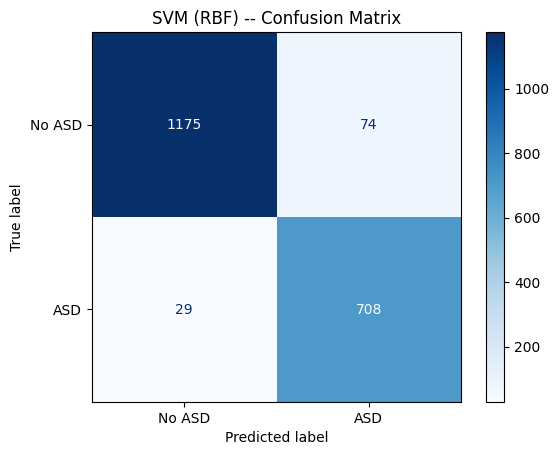

In [27]:
y_pred_best = predictions[best_model_name]

print(f"=== {best_model_name} -- classification report ===")
print(classification_report(y_test, y_pred_best, digits=3))

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No ASD", "ASD"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"{best_model_name} -- Confusion Matrix")
plt.show()

In [28]:
for name in fitted_models:
    print(f"\n{name}")
    print(classification_report(y_test, predictions[name], digits=3))
    print("=" * 60)


Logistic Regression
              precision    recall  f1-score   support

           0      0.974     0.910     0.941      1249
           1      0.863     0.959     0.909       737

    accuracy                          0.928      1986
   macro avg      0.919     0.935     0.925      1986
weighted avg      0.933     0.928     0.929      1986


Random Forest
              precision    recall  f1-score   support

           0      0.957     0.920     0.938      1249
           1      0.873     0.929     0.900       737

    accuracy                          0.923      1986
   macro avg      0.915     0.925     0.919      1986
weighted avg      0.925     0.923     0.924      1986


SVM (RBF)
              precision    recall  f1-score   support

           0      0.976     0.941     0.958      1249
           1      0.905     0.961     0.932       737

    accuracy                          0.948      1986
   macro avg      0.941     0.951     0.945      1986
weighted avg      0.950    

## 9. Save all the models

Every tuned candidate (Logistic Regression, Random Forest, SVM, Decision Tree) is saved to its own file, not just the winner -- useful for comparing them later, swapping the "best" model for a different one (e.g. a faster or more interpretable model), or running an ensemble. Each saved object is the **full pipeline** (preprocessing + SMOTE + classifier), so any of them can be loaded and called with `.predict()` directly on raw data.

Files are written into the `models/` folder alongside this notebook, following the pattern `asd_model_<model_name>.joblib`. The overall best model (by cross-validated F1) is additionally saved as `asd_best_model.joblib` for convenience.

**Note:** because `SmotePipeline` and `smote_resample` are defined in this notebook rather than in an installed package, loading these `.joblib` files back requires those two definitions to be available in the environment doing the loading (e.g. by re-running the cell that defines them, or moving them into a small local `.py` module first). This is the same requirement any custom estimator has when pickled with `joblib`/`pickle`.


In [29]:
import re

def slugify(name):
    return re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")

saved_model_paths = {}
for name, model in fitted_models.items():
    filename = f"asd_model_{slugify(name)}.joblib"
    joblib.dump(model, MODELS_DIR / filename)
    saved_model_paths[name] = filename
    print(f"Saved {name:22s} -> {MODELS_DIR / filename}")

joblib.dump(best_model, MODELS_DIR / "asd_best_model.joblib")
saved_model_paths["Best (" + best_model_name + ")"] = "asd_best_model.joblib"
print(f"\nSaved best model ({best_model_name}) -> {MODELS_DIR / 'asd_best_model.joblib'}")

metadata = {
    "best_model_name": best_model_name,
    "saved_model_paths": saved_model_paths,
    "features": list(X.columns),
    "categorical_features": cat_features,
    "numerical_features": num_features,
    "all_model_test_metrics": validation_results.round(4).to_dict(orient="index"),
}
joblib.dump(metadata, MODELS_DIR / "asd_model_metadata.joblib")
print(f"Saved metadata -> {MODELS_DIR / 'asd_model_metadata.joblib'}")

Saved Logistic Regression    -> e:\ML project\ASD_Prediction\models\asd_model_logistic_regression.joblib
Saved Random Forest          -> e:\ML project\ASD_Prediction\models\asd_model_random_forest.joblib
Saved SVM (RBF)              -> e:\ML project\ASD_Prediction\models\asd_model_svm_rbf.joblib
Saved Decision Tree          -> e:\ML project\ASD_Prediction\models\asd_model_decision_tree.joblib

Saved best model (SVM (RBF)) -> e:\ML project\ASD_Prediction\models\asd_best_model.joblib
Saved metadata -> e:\ML project\ASD_Prediction\models\asd_model_metadata.joblib


## 10. Load a saved model back and predict on a new patient

This demonstrates the full deployment loop: load a saved pipeline -- the code below defaults to the best model, but any of the individually saved candidates works the same way -- and feed it one raw, un-encoded row shaped like the original data (the pipeline handles scaling and one-hot encoding internally). For comparison, a second saved model (Logistic Regression) is loaded and run on the same patient to check whether the two agree.

In [30]:
metadata = joblib.load(MODELS_DIR / "asd_model_metadata.joblib")
print("Available saved models:")
for name, path in metadata["saved_model_paths"].items():
    print(f"  - {name:28s} -> {MODELS_DIR / path}")

loaded_model = joblib.load(MODELS_DIR / "asd_best_model.joblib")

new_patient_scores = {
    "A1_Score": 1, "A2_Score": 1, "A3_Score": 0, "A4_Score": 1, "A5_Score": 1,
    "A6_Score": 0, "A7_Score": 1, "A8_Score": 1, "A9_Score": 0, "A10_Score": 1,
}
new_patient = pd.DataFrame([{
    **new_patient_scores,
    "age": 27, "gender": 1, "ethnicity": "White-European", "jundice": 0,
    "austim": 0, "contry_of_res": "United States", "used_app_before": 0,
    "relation": "Self",
}])

pred = loaded_model.predict(new_patient)[0]
proba = loaded_model.predict_proba(new_patient)[0][1] if hasattr(loaded_model, "predict_proba") else None

print("\nPrediction:", "ASD traits likely" if pred == 1 else "ASD traits unlikely")
if proba is not None:
    print(f"Predicted probability of ASD traits: {proba:.3f}")

lr_path = metadata["saved_model_paths"]["Logistic Regression"]
loaded_lr = joblib.load(MODELS_DIR / lr_path)
lr_pred = loaded_lr.predict(new_patient)[0]
print(f"\nLogistic Regression prediction on same patient: {'ASD traits likely' if lr_pred == 1 else 'ASD traits unlikely'}")


Available saved models:
  - Logistic Regression          -> e:\ML project\ASD_Prediction\models\asd_model_logistic_regression.joblib
  - Random Forest                -> e:\ML project\ASD_Prediction\models\asd_model_random_forest.joblib
  - SVM (RBF)                    -> e:\ML project\ASD_Prediction\models\asd_model_svm_rbf.joblib
  - Decision Tree                -> e:\ML project\ASD_Prediction\models\asd_model_decision_tree.joblib
  - Best (SVM (RBF))             -> e:\ML project\ASD_Prediction\models\asd_best_model.joblib

Prediction: ASD traits likely
Predicted probability of ASD traits: 0.902

Logistic Regression prediction on same patient: ASD traits unlikely
